## Задание
1. Построить классификатор изображений рукописного ввода на базе MNIST. В качестве шаблона в данной работе можно использовать ipython-ноутбук 002-digit.ipynb.
2. Классификатор предлагается строить на признаках, полученных в результате предобработки изображений, например, гистограммы градиентов (HOG) или результат PCA преобразования.
3. В качестве модели классификатора можно использовать любую известную Вам модель, за исключением сверточных нейронных сетей.
4. Критерием качества классификатора является метрика accuracy. Для получения зачета по данной работе, значение метрики accuracy должно быть больше 0.6. Метрика оценивается на тестовой выборке в рамках контеста Digit Recognizer на Kaggle.
5. Решение необходимо предоставить в виде ipython-ноутбука с реализацией процесса построения модели и скриншота с финальным результатом на Kaggle.

In [90]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [5]:
train = np.loadtxt('./digit/train.csv', delimiter=',', skiprows=1)
test = np.loadtxt('./digit/test.csv', delimiter=',', skiprows=1)

In [115]:
np.unique(test[:,0])

array([0.])

## Порядок построение классификационной модели:
1. Обработка данных - создание признаков на основе гистограммы градиентов
- нахождение градиента по X и Y через оператор Собеля
- нахождение длины градиента по формуле
- нахождение угла наклона градиента в полярной системе координат
- нахождение гистограммы градиента
- нормирование вектора гистограммы градиента
2. Разделение обучающей выборки на обучение и валидацию 
3. Обучение модели SVM
4. Оценка качества на тестовой выборке


## Генерация признаков

### Подготовка данных

In [107]:
# сохраняем разметку в отдельную переменную
train_label = train[:, 0]
test_label = test[:,0]
# приводим размерность к удобному для обаботки виду - mathplotlib ожидает для входа изображение с 3 матрицами, а не с 2-мя, поэтому вторую матрицу 785 пикселей мы преобразуем в две 28х28
train_img = np.resize(train[:, 1:], (train.shape[0], 28, 28)) ## train[:, 1:] - массив, размер которого надо изменить (второй столбец, так как в первом хранятся лэйблы чисел), (train.shape[0], 28, 28) - размер новой матрицы 
test_img = np.resize(test, (test.shape[0], 28, 28)) 


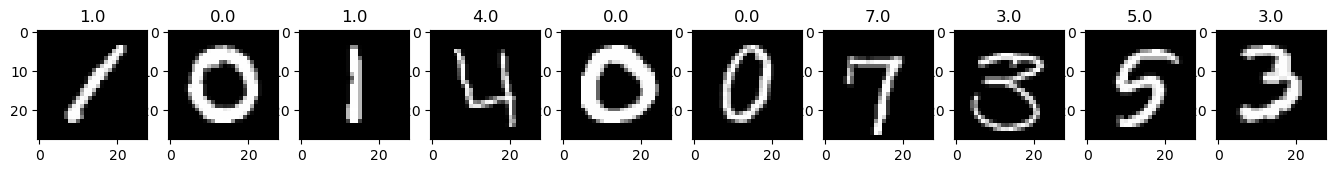

In [35]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(train_img[0:10], 1): ## # Выводит индекс  (c единицы) и значение (изображение)
    subplot = fig.add_subplot(1, 12, i) ## размещение нескольких графиков на одном графике
    plt.imshow(img, cmap='gray')
    subplot.set_title('%s' % train_label[i - 1])
plt.show()

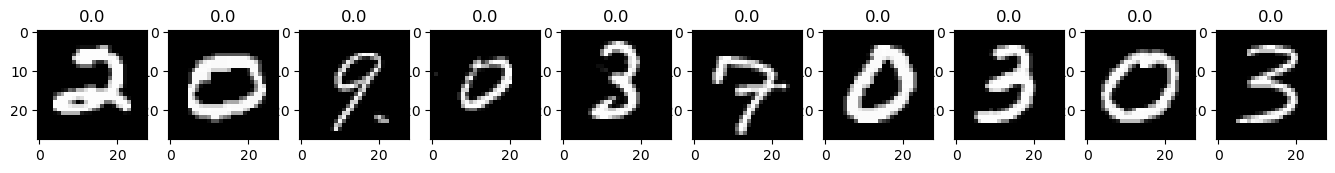

In [116]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(test_img[0:10], 1): ## # Выводит индекс  (c единицы) и значение (изображение)
    subplot = fig.add_subplot(1, 12, i) ## размещение нескольких графиков на одном графике
    plt.imshow(img, cmap='gray')
    subplot.set_title('%s' % test_label[i - 1])
plt.show()

### Вычислени градиентов по оператору Собеля

In [44]:
train_grad_x = np.zeros_like(train_img) ## заполняем нулями
train_grad_y = np.zeros_like(train_img) ## заполняем нулями
 
for i in range(len(train_img)): ## для каждого изображения (из 4200) будем вычислять свой оператор Собеля
    train_grad_x[i] = cv2.Sobel(train_img[i],cv2.CV_64F,dx=1,dy=0,ksize=3)
    train_grad_y[i] = cv2.Sobel(train_img[i],cv2.CV_64F,dx=0,dy=1,ksize=3)


In [45]:
test_grad_x = np.zeros_like(test_img) ## заполняем нулями
test_grad_y = np.zeros_like(test_img) ## заполняем нулями
 
for i in range(len(test_img)): ## для каждого изображения (из 4200) будем вычислять свой оператор Собеля
    test_grad_x[i] = cv2.Sobel(test_img[i],cv2.CV_64F,dx=1,dy=0,ksize=3)
    test_grad_y[i] = cv2.Sobel(test_img[i],cv2.CV_64F,dx=0,dy=1,ksize=3)

### Вычисление угла и длины вектора градиентов

In [47]:
train_g, train_tetta = cv2.cartToPolar(train_grad_x,train_grad_y)
test_g,test_tetta = cv2.cartToPolar(test_grad_x,test_grad_y)

### Вычисление гистограммы градиента

In [52]:
train_hist = np.zeros((len(train_img),16)) ## 16 - так как будем смотреть распределение градиента в квадрате 16 пикселей 

for i in range(len(train_img)):
    hist, borders = np.histogram(train_tetta[i],bins=16,range=(0,2*np.pi),weights=train_g[i])
    train_hist[i] = hist


In [70]:
test_hist = np.zeros((len(test_img),16))

for i in range (len(test_img)):
    hist,borders = np.histogram(test_tetta[i],bins=16,range=(0,2*np.pi),weights=test_g[i])
    test_hist[i] = hist

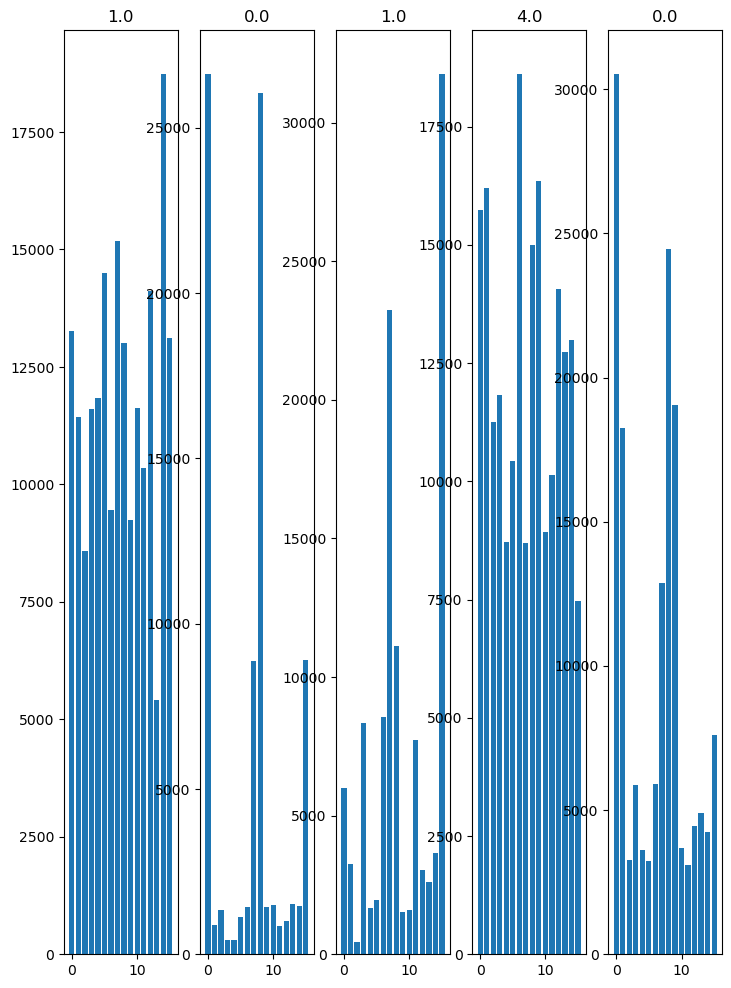

In [69]:
fig = plt.figure(figsize=(12, 12))
for i, img in enumerate(train_img[0:5], 1): ## # Выводит индекс  (c единицы) и значение (изображение)
    subplot = fig.add_subplot(1, 7, i) ## размещение нескольких графиков на одном графике
    plt.bar(np.arange(16), train_hist[i])
    subplot.set_title('%s' % train_label[i - 1])
plt.show()


### Нормирование вектора гистограммы градиентов

In [79]:
"""
1. np.linalg.norm(train_hist, axis=1)
Вычисляет длину (норму) каждого вектора гистограммы.
То есть для каждого изображения находит длину вектора из 16 чисел:
2. [:, None]
превращает этот вектор норм в столбец формы (n_samples, 1),
чтобы можно было корректно делить построчно.

"""
train_hist = train_hist/np.linalg.norm(train_hist,axis=1)[:,None]
test_hist = test_hist/np.linalg.norm(test_hist,axis=1)[:,None]



### Разделение выборки на обучение и валидацию

In [86]:
X_train,X_val,y_train,y_val = train_test_split(train_hist,train_label,test_size=0.2,random_state=42)


## Обучение модели SVM (SVC)

In [96]:
model_SVC_rbf = SVC(kernel='rbf')
model_SVC_rbf.fit(X_train,y_train)
y_pred_val_rbf = model_SVC_rbf.predict(X_val)


In [97]:
model_SVC_poly = SVC(kernel='poly')
model_SVC_poly.fit(X_train,y_train)
y_pred_val_poly = model_SVC_poly.predict(X_val)

In [99]:
model_SVC_sigm = SVC(kernel='sigmoid')
model_SVC_sigm.fit(X_train,y_train)
y_pred_val_sigm = model_SVC_sigm.predict(X_val)

In [101]:
model_SVC_lin = SVC(kernel='linear')
model_SVC_lin.fit(X_train,y_train)
y_pred_val_lin = model_SVC_lin.predict(X_val)

### Оценка точности на валидационной выборке

In [102]:
print(f'Точность модели при ядре rbf {accuracy_score(y_val,y_pred_val_rbf):.2f}, \nТочность модели при ядре poly {accuracy_score(y_val,y_pred_val_poly):.2f},\nТочность модели при ядре sigmoid {accuracy_score(y_val,y_pred_val_sigm):.2f},\nТочность модели при ядре linear {accuracy_score(y_val,y_pred_val_lin):.2f}')

Точность модели при ядре rbf 0.65, 
Точность модели при ядре poly 0.66,
Точность модели при ядре sigmoid 0.17,
Точность модели при ядре linear 0.59


Самая высокая точность на валидационной выборке наблюдается у модели с ядром poly

### Оценка точности на тестовой выборке

In [122]:
y_pred_test = model_SVC_poly.predict(test_hist)

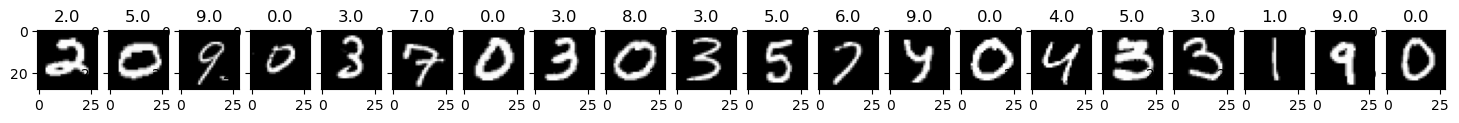

In [124]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(test_img[0:20], 1):
    subplot = fig.add_subplot(1, 22, i)
    plt.imshow(img, cmap='gray')
    subplot.set_title('%s' % y_pred_test[i - 1])
plt.show()

Модель предсказывает цифры на изображении с точностью 66 процентов, что достаточно низко. На изображениях выше видно, что модель ошибается в цифрах 5, 8,9,6 хотя бы один раз. Попробуем обучить другую модель

## Обучение модели Random Forest

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [135]:


rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions={
        'n_estimators': [10, 50, 75, 100, 150],
        'max_depth': [1, 3, 5, 7, 10],
        'min_samples_split': [2, 3, 5, 7, 10]
    },
    n_iter=20,  # число случайных комбинаций
    n_jobs=-1,
    cv=3,
    random_state=42
)
rand_search.fit(X_train, y_train)


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [1, 3, 5, 7, 10],
                                        'min_samples_split': [2, 3, 5, 7, 10],
                                        'n_estimators': [10, 50, 75, 100, 150]},
                   random_state=42)

In [159]:
model_RF = RandomForestClassifier(n_estimators=100)
model_RF.fit(X_train,y_train)
y_pred_val_RF = model_RF.predict(X_val)

In [161]:
accuracy_score(y_val,y_pred_val_RF)

0.6435714285714286

In [162]:
y_pred_test_RF = model_RF.predict(test_hist)

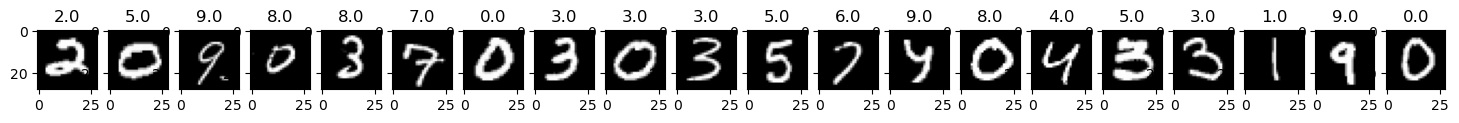

In [163]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(test_img[0:20], 1):
    subplot = fig.add_subplot(1, 22, i)
    plt.imshow(img, cmap='gray')
    subplot.set_title('%s' % y_pred_test_RF[i - 1])
plt.show()

Модель показывает еще ниже точность.